<div align="center">

# INSA TOULOUSE

### Génie Électrique et Informatique (3IMACS)

---

## UF A3AEAU11 – Control of Linear Systems

### *Automatic Control Project : Balancing of a Two-Wheeled LEGO Robot*

⚠️ **This notebook must be run in the web version of Jupyter Notebook.**
**Running it in the desktop application will cause errors when importing the `animation` module.**

</div><br><br>

### Membres du binôme
* **Student 1 :** [Your First Name / Last Name]
* **Student 2 :** [Your First Name / Last Name]
* **Submission Date :** TBD

# 1. Objectives
&emsp;The objective of this project is twofold.<br>
&emsp;On the one hand, the goal is to introduce the use of the software Matlab, in the framework of automatic control. In addition to the basic functionalities of the software, you will be brought to complete your training by using the specific toolboxes that are Control toolbox and Simulink.<br>
&emsp;On the other hand, a second objective (perhaps more ambitious) consists in making a small synthesis of your knowledge in automatic control. Indeed, starting from a concrete case study of a two-wheeled robot built with LEGO Mindstorms, you will try to conduct a reflection that will require you, using different techniques of automatic control, to have a more global look on what you are doing. Thus, a particular attention will be asked to interpret the results as well as the adequacy of the tools used.<br>
&emsp;Throughout this study, you will have to write python code between questions that will allow you to execute simulations as well as the plotting of results curves. The advantage of a live script is that it contains your code, output, and formatted text together in a single interactive environment called the Live Editor. In live scripts, you can write your code and view the generated output and graphics along with the code that produced it. You can also add formatted text, images, hyperlinks, and equations to create an interactive narrative that you can share with others.<br>
&emsp;**All your work must be included in this notebook that would be used as your report. An exported pdf version of the live script can also be provided as your report. Pay attention to include all your code, plots, analyses, comments, and conclusion in your file.**<br>
&emsp;**For more information about the libraries you'll have to use during this project, look at the appendix at the end !**<br>

# 2. The two-wheeled robot
<br><br><br>
<div align="center">
  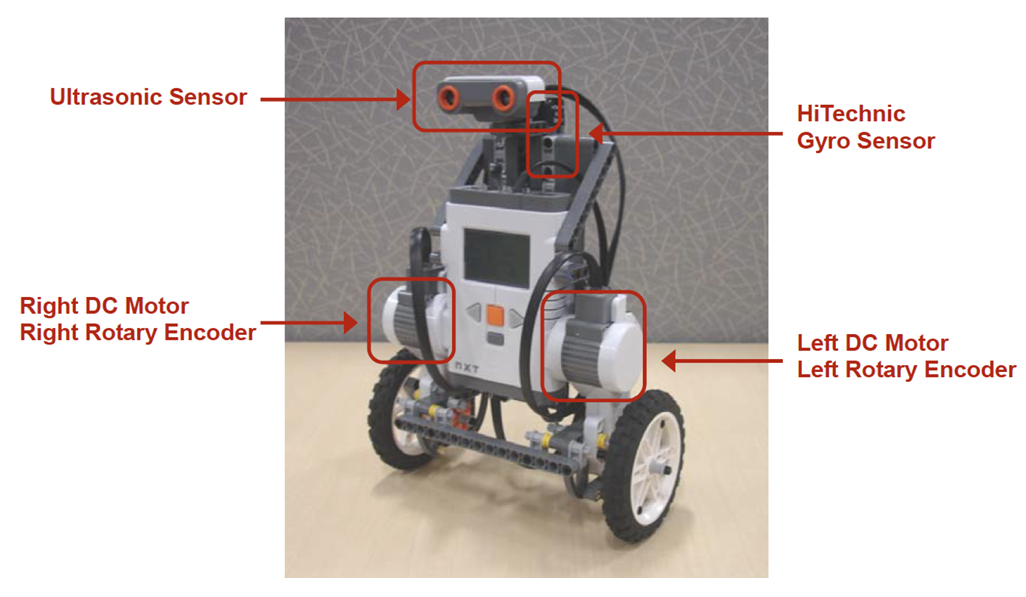
  <br>
  <span style="font-style: italic; color: #555;">Figure 1: The NXTway-GS system.</span>
</div><br><br><br>

&emsp; The system considered in this project (see Figure 1) is a NXTway-GS self-balancing two-wheeled robot built with LEGO Mindstorms NXT.

&emsp; The robot is equipped of several actuators and sensors :

&emsp;&mdash; 2 DC Motors (right and left) whose speed is controlled by PWM (Pulse Width Modulation). The input of the DC motors is noted u.

&emsp;&mdash; 2 rotary encoders (one for each wheel) that provide an angle measurement in degree. This measurement called the DC motor angle is denoted $\theta_{ml,r}$ for the right and left motor respectively.

&emsp;&mdash; An ultrasonic sensor that gives a distance measurement in centimeter to compute for instance the distance to a wall.

&emsp; &mdash; A Gyro sensor that provides an angular velocity in degree per second. This sensor provides the body pitch angular velocity noted $\dot{\psi}$.

&emsp; The NXTway-GS can be considered as a two wheeled inverted pendulum model, shown Figure 2.<br>
&emsp; The side and plane view of the system are given Figure 3 with $\theta$ the average angle of left and tight wheel, $\psi$ the body pitch angle and $\phi$ the body yaw angle.


# 3. Process modeling

<br><br><br>
<div align="center">
  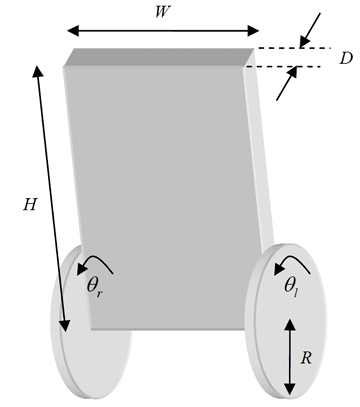
  <br>
  <span style="font-style: italic; color: #555;">Figure 2: Schematic view of the system as an inverted pendulum.</span>
</div><br><br<br><br><br><br><br><br>

<div align="center">
  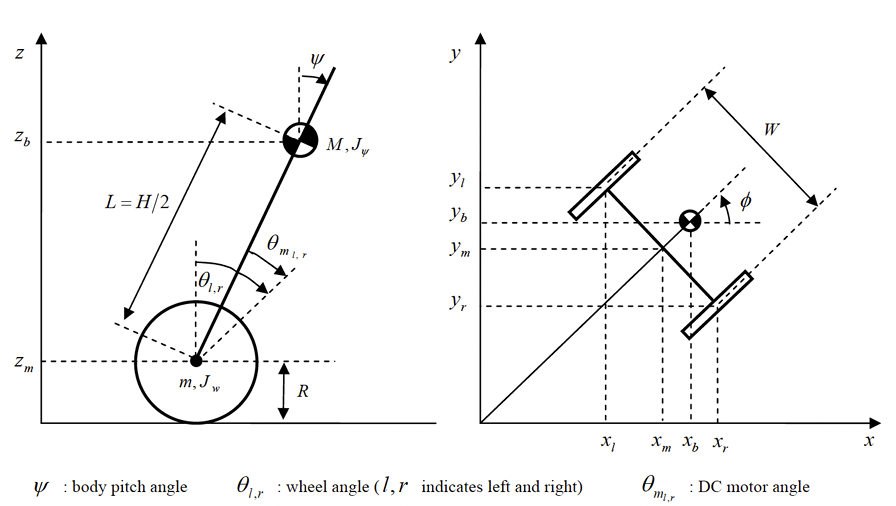
  <br>
  <span style="font-style: italic; color: #555;">Figure 3: Side and plane view of the two-wheeled inverted pendulum.</span>
</div><br><br><br>

&emsp; We can derive motion equations of the two-wheeled inverted pendulum by the Lagrangian method based on the coordinate system given Figure 3. More details on this modelling step are given in the file Annexe available on Moodle. After a linearization step, the motion equations are approximated as follows :

$$ [(2m+M)R^{2}+2J_{w}+2n^{2}J_{m}]\ddot{\theta} + (MLR-2n^{2}J_{m})\ddot{\psi} = F_{\theta} \qquad (1)$$
$$ (MLR-2n^{2}J_{m})\ddot{\theta} + (ML^{2}+J_{\psi}+2n^{2}J_{m})\ddot{\psi} - MgL\psi = F_{\psi} \qquad (2)$$
$$ [\frac{1}{2}mW^{2} + J_{\phi} + \frac{W^{2}}{2R^{2}}(J_{\omega} + n^{2}J_{m})]\ddot{\phi}= F_{\phi} \qquad (3)$$

&emsp; where :<br>
&emsp; &mdash; m, M denote the wheel and the body weight (in Kg) respectively<br>
&emsp; &mdash; W is the body wide (in meters).<br>
&emsp; &mdash; L the distance od the center of mass from the wheel axle in meters.<br>
&emsp; &mdash; R is the wheel radius (in meters).<br>
&emsp; &mdash; n is the gear ratio.<br>
&emsp; &mdash; $J_{\omega}, J_{\psi}, J_{\phi}$ and $J_{m}$ are the inertia moment of the wheel, the body pitvh, body yaw and DC motor respectively (expressed in $Kg.m^{2}$).<br>
&emsp; &mdash; $\theta$ the average angle of left and right wheel in radian.<br>
&emsp; &mdash; $\psi$ the body pitch angle in radian.<br>
&emsp; &mdash; $\phi$ the body yaw angle in radian.<br>
&emsp; &mdash; $F_{\theta}, F_{\psi}$ and $F_{\phi}$ are the generalized forces.<br>

&emsp; These forces can be expressed using the motors' voltage ($v_l$ and $v_r$) taking into account the friction coefficients $f_m$ (between the body and DC motor) and $f_\omega$ (between the wheel and the floor), but also the DC motor torque constant (noted $K_{t}$ (N.m/A)) and the parameters of the DC motors  
($K_b$ the back EMF constant (V.s/rad) and $R_m$ motor resistance (ohms).

$$F_{\theta} = \alpha(v_l+v_r) - 2(\beta+f_w)\dot{\theta} + 2\beta\dot{\psi} \qquad (4)$$
$$F_{\psi} = -\alpha(v_l+v_r) + 2\beta\dot{\theta} - 2\beta\dot{\psi} \qquad (5)$$
$$F_{\phi} = \frac{W}{2R}\alpha(v_r-v_l) - \frac{W^2}{2R^2}(\beta+f_\omega)\dot{\phi} \qquad (6)$$

With : $\alpha = \frac{nK_{t}}{R_{m}}$ and $\beta = \frac{nK_{t}K_{b}}{R_{m}} + f_{m}$.

&emsp; Looking at the motion equations (1) to (3), it appears that the two first equations depend only on $\psi$ and $\phi$ whereas the last one depends only on $\theta$. It is then possible to model the system by considering two sub-systems given by :

$$ E \begin{bmatrix} \ddot{\theta} \\ \ddot{\psi} \end{bmatrix} + F \begin{bmatrix} \dot{\theta} \\ \dot{\psi} \end{bmatrix} + G \begin{bmatrix} \theta \\ \psi \end{bmatrix} = H \begin{bmatrix} v_l \\ v_r \end{bmatrix} \qquad (7) $$
$$[\frac{1}{2}mW^2 + J_\phi + \frac{W^2}{2R^2}(J_\omega + n^2J_m)]\ddot{\phi} + \frac{W^2}{2R^2}(\beta+f_\omega)\dot{\phi} = \frac{W}{2R}\alpha(v_r-v_l)$$

## 3.1  MIMO (Multiple Input Multiple Output) state space models

The robot's parameters are initialized in the next section. Please ensure you run that cell before starting any calculations. Write your Python code and answers in the dedicated cells following each question.

In [2]:
import numpy as np
import math

# Parameters of the  two-wheel robot

# Physical Constant

g = 9.81  # gravity acceleration [m/sec^2]

# Lego Mindstorms EV3 Parameters
m = 0.03  # wheel weight [kg] valor inicial 0.03
R = 0.042  # wheel radius [m]  valor inicial 0.04
Jw = m * R**(2) / 2  # wheel inertia moment [kgm^2]

####################################################################
M = 0.8  # body weight [kg] 
W = 0.152  # body width [m]
D = 0.055  # body depth [m]
H = 0.160  # body height [m]

####################################################################
L = H / 2  # distance of the center of mass from the wheel axle [m]
Jpsi = M * L ** 2 / 3  # body pitch inertia moment [kgm^2]
Jphi = M * (W ** 2 + D ** 2) / 12  # body yaw inertia moment [kgm^2]
fm = 0.0022  # friction coefficient between body & DC motor
fw = 0  # friction coefficient between wheel & floor

# DC Motor Parameters

Jm = 1e-5  # DC motor inertia moment [kgm^2]

###################################################################
Rm = 6.69  # DC motor resistance [ƒ¶]
Kb = 0.468  # DC motor back EMF constant [Vsec/rad]
###################################################################
Kt = 0.317  # DC motor torque constant [Nm/A]
###################################################################
n = 1  # gear ration

beta = n * Kt * Kb / Rm + fm
alpha = n * Kt / Rm
tmp = beta + fw

**Question 1** From the subsystem of (8) and by considering the state vector $x_2 = \begin{bmatrix} \phi \\ \dot{\phi} \end{bmatrix}$ and the input vector $u = \begin{bmatrix} v_l \\ v_r \end{bmatrix}$, compute the matrices of the state space model $\dot{x_2} = A_2x_2 + B_2u$

In [3]:
I = m * W ** 2 / 2 + Jphi + (Jw + n ** 2 * Jm) * W ** 2 / (2 * R ** 2)
J = tmp * W ** 2 / (2 * R ** 2)
K = alpha * W / (2 * R)

A2 = np.array([[0, 1], [0, -J / I]])
B2 = np.array([[0, 0], [-K / I, K / I]])
C2 = np.identity(2)
D2 = np.zeros((2, 2))

**Question 2** From the subsystem given by (7) and by considering (1) and (2), compute the matrices E, F, G and H.

The linearized equations of motion are given by:
$$[(2m+M)R^{2}+2J_{w}+2n^{2}J_{m}]\ddot{\theta}+(MLR-2n^{2}J_{m})\ddot{\psi} = F_{\theta} \qquad (1)$$
$$(MLR-2n^{2}J_{m})\ddot{\theta}+(ML^{2}+J_{\psi}+2n^{2}J_{m})\ddot{\psi}-MgL\psi = F_{\Psi} \qquad (2)$$

Where the generalized forces are expressed as:
$$F_{\theta} = \alpha(v_{l}+v_{r})-2(\beta+f_{w})\dot{\theta}+2\beta\dot{\psi} \qquad (4)$$
$$F_{\psi} = -\alpha(v_{l}+v_{r})+2\beta\dot{\theta}-2\beta\dot{\psi} \qquad (5)$$

---

#### 1. Substituting and Rearranging Terms

By substituting equations (4) and (5) into (1) and (2), and moving all state-dependent variables ($\ddot{\theta}, \ddot{\psi}, \dot{\theta}, \dot{\psi}, \theta, \psi$) to the left-hand side, we obtain:

**From Equation (1):**
$$[(2m+M)R^{2}+2J_{w}+2n^{2}J_{m}]\ddot{\theta} + (MLR-2n^{2}J_{m})\ddot{\psi} + 2(\beta+f_{w})\dot{\theta} - 2\beta\dot{\psi} = \alpha v_l + \alpha v_r$$

**From Equation (2):**
$$(MLR-2n^{2}J_{m})\ddot{\theta} + (ML^{2}+J_{\psi}+2n^{2}J_{m})\ddot{\psi} - 2\beta\dot{\theta} + 2\beta\dot{\psi} - MgL\psi = -\alpha v_l - \alpha v_r$$

---

#### 2. Matrix Form Representation

We want to write this subsystem in the following standard form:
$$E \begin{bmatrix} \ddot{\theta} \\ \ddot{\psi} \end{bmatrix} + F \begin{bmatrix} \dot{\theta} \\ \dot{\psi} \end{bmatrix} + G \begin{bmatrix} \theta \\ \psi \end{bmatrix} = H \begin{bmatrix} v_l \\ v_r \end{bmatrix} \qquad (7)$$

By identifying the coefficients for each vector, we find the following system matrices:

$$E = \begin{bmatrix} (2m+M)R^{2}+2J_{w}+2n^{2}J_{m} & MLR-2n^{2}J_{m} \\ MLR-2n^{2}J_{m} & ML^{2}+J_{\psi}+2n^{2}J_{m} \end{bmatrix}$$

$$F = \begin{bmatrix} 2(\beta+f_{w}) & -2\beta \\ -2\beta & 2\beta \end{bmatrix}$$

$$G = \begin{bmatrix} 0 & 0 \\ 0 & -MgL \end{bmatrix}$$

$$H = \begin{bmatrix} \alpha & \alpha \\ -\alpha & -\alpha \end{bmatrix}$$

**Question 3** By considering the state vector $x_1 = \begin{bmatrix} \theta \\ \psi \\ \dot{\theta} \\ \dot{\psi} \end{bmatrix}$ and the input $u = \begin{bmatrix} v_l \\ v_r \end{bmatrix}$, compute the matrices of the state space model $x_1 = A_1x_1 + B_1u$

In [4]:
E_11 = (2 * m + M) * R**(2) + 2 * Jw + 2 * n**(2) * Jm
E_12 = M * L * R - 2 * n ** 2 * Jm
E_22 = M * L ** 2 + Jpsi + 2 * n ** 2 * Jm
detE = E_11 * E_22 - E_12 ** 2

A1_32 = -g * M * L * E_12 / detE
A1_42 = g * M * L * E_11 / detE
A1_33 = -2 * (tmp * E_22 + beta * E_12) / detE
A1_43 = 2 * (tmp * E_12 + beta * E_11) / detE
A1_34 = 2 * beta * (E_22 + E_12) / detE
A1_44 = -2 * beta * (E_11 + E_12) / detE
B1_3 = alpha * (E_22 + E_12) / detE
B1_4 = -alpha * (E_11 + E_12) / detE

# State-Space Matrix Calculation - MIMO model

A1 = np.array([[0, 0, 1, 0], [0, 0, 0, 1], [0, A1_32, A1_33, A1_34], [0, A1_42, A1_43, A1_44]])
B1 = np.array([[0, 0], [0, 0], [B1_3, B1_3], [B1_4, B1_4]])
C1 = np.identity(4)
D1 = np.zeros((4, 2))

## 3.2  SISO (Single Input Single Output) state space model

The models obtained previously consider an input vector $u = \begin{bmatrix} v_l \\ v_r \end{bmatrix}$ to control the trajectory of the robot, but also the balance. In the remainder we will consider first only the problem of balance assuming a same imput u for each wheel given by :
$$ u = \frac{v_l+v_r}{2}$$

**Question 4** Generate the state space model for the balance control problem. Consider $\theta(t)$ as output.

In [5]:
%pip install control

In [6]:
import control as ctrl

In [7]:
A = A1
B = 2*B1[:, 0].reshape(4, 1)
C = np.array([1, 0, 0, 0])
D = 0
sysbo = ctrl.ss(A, B, C, D)
print(sysbo)

<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[   0.            0.            1.            0.        ]
     [   0.            0.            0.            1.        ]
     [   0.         -444.58852126 -123.11348321  123.11348321]
     [   0.          264.94676359   55.09518151  -55.09518151]]

B = [[   0.        ]
     [   0.        ]
     [ 239.3206408 ]
     [-107.09967584]]

C = [[1. 0. 0. 0.]]

D = [[0.]]


# 4   Simulation of the open loop system

**Question 5** Provide a plot of the step response of your model, for 5 seconds.

In [8]:
import matplotlib.pyplot as plt

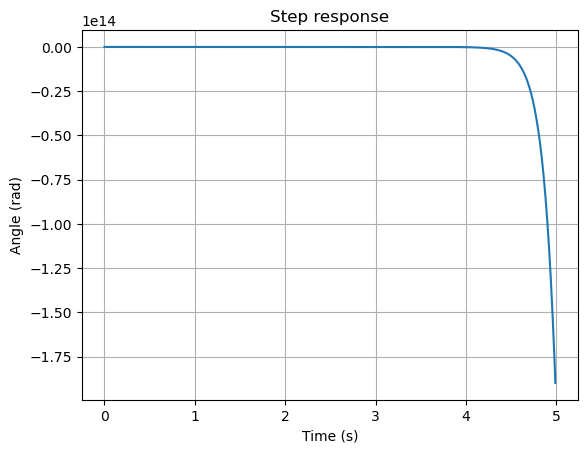

In [9]:
dt = 0.01
tf = 5
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])
tout, theta = ctrl.step_response(sysbo, t, x0)

fig1, ax1 = plt.subplots()
ax1.plot(tout, theta)

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Angle (rad)')
ax1.set_title('Step response')
ax1.grid(True)

**Question 6** Provide the same simulation using the solve_ivp function. You should also use the xdot function defined below. Plot theta and psi on the same plot.

In [10]:
from scipy.integrate import solve_ivp

In [11]:
def xdot(t, xin, Kin, lcin, amplitude):
    """
    Computes the state derivative vector (xdot) for the non-linear 
    two-wheeled robot (inverted pendulum) simulation.

    Parameters
    ----------
    t : float
        Current simulation time (in seconds)
    xin : array_like (shape(4,))
        Current state vector at time t :
        - xin[0] : theta, mean angular wheel position [rad]
        - xin[1] : psi, body pitch tilt angle [rad]
        - xin[2] : dtheta, mean angular wheel velocity [rad/s]
        - xin[3] : dpsi, body pitch angular velocity [rad/s]
    Kin : numpy.ndarray (shape (1, 4))
        State feedback controller gain matrix (u = -K*x + lc*yc).
    lcin : float
        Feedforward pregain.
    amplitude : float
        The target amplitude or final value of the step input [rad].

    Returns
    -------
    list(len 4)
        The state derivative vector [xdot1, xdot2, xdot3, xdot4], where:
        - xdot1 : dtheta (wheel velocity)
        - xdot2 : dpsi (body pitch velocity)
        - xdot3 : ddtheta (wheel acceleration)
        - xdot4 : ddpsi (body pitch acceleration)
    """
    # positionvector
    theta = xin[0]  # angular position of thewheel
    psi = xin[1]  # angular positionof the gyropode
    # speedvector
    dtheta = xin[2]  # angular speed of thewheel
    dpsi = xin[3]  # angularspeed of the gyropode

    # compute u
    x = np.reshape(xin, (4, 1))
    uth = -(np.dot(Kin, x)) + lcin * amplitude
    uth = uth[0, 0]
    u = np.clip(uth, -8.0, 8.0)

    # computes the value of the x dot vector (state derivative)

    i = 1 / Rm * (u + Kb * (dpsi - dtheta))

    Ftheta = 2 * alpha * u - 2 * beta * (dtheta - dpsi) - 2 * fw * dtheta

    Fpsi = -2 * alpha * u + 2 * beta * (dtheta - dpsi)

    M1 = np.array([[(2 * m + M) * R ** 2 + 2 * Jw + 2 * n ** 2 * Jm, M * L * R * math.cos(psi) - 2 * n ** 2 * Jm],
                   [M * L * R * math.cos(psi) - 2 * n ** 2 * Jm, M * L ** 2 + Jpsi + 2 * n ** 2 * Jm]])
    M2 = np.array([[Ftheta + M * L * R * dpsi ** 2 * math.sin(psi)],
                   [Fpsi + M * g * L * math.sin(psi)]])

    var = np.linalg.solve(M1, M2)

    xdot1 = dtheta
    xdot2 = dpsi
    xdot3 = var[0, 0]
    xdot4 = var[1, 0]

    return [xdot1, xdot2, xdot3, xdot4]

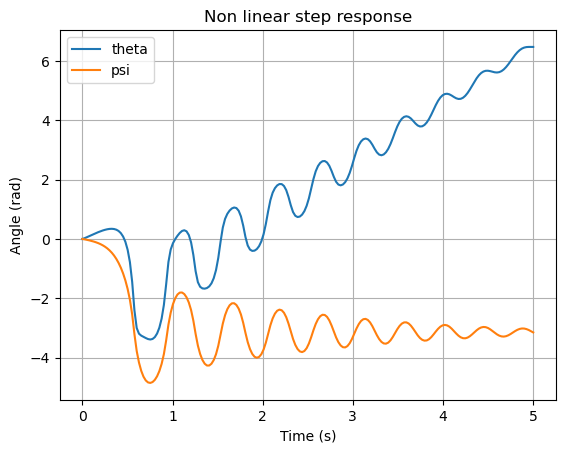

In [12]:
tspan = (0.0, 5.0)
t_eval = np.linspace(tspan[0], tspan[1], num=200)
x0 = [0.0, 0.0, 0.0, 0.0]
amplitude = 1
sol_bo = solve_ivp(xdot, tspan, x0, t_eval=t_eval, method='RK45', args=(0, 1, amplitude))

t = sol_bo.t
xout = sol_bo.y
theta_nlin_bo = sol_bo.y[0, :]
psi_nlin_bo = sol_bo.y[1, :]

fig2, ax2 = plt.subplots()
ax2.plot(t, theta_nlin_bo, label='theta')
ax2.plot(t, psi_nlin_bo, label='psi')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Angle (rad)')
ax2.set_title('Non linear step response')
ax2.legend()
ax2.grid(True)

**Question 7** Provide the same simulation using the lsim function of the signal library.

NB : The lsim function is provided in the signal library, you have to create the state-space model using `signal.StateSpace(A, B, C, D)` before using lsim.

In [13]:
from scipy import signal

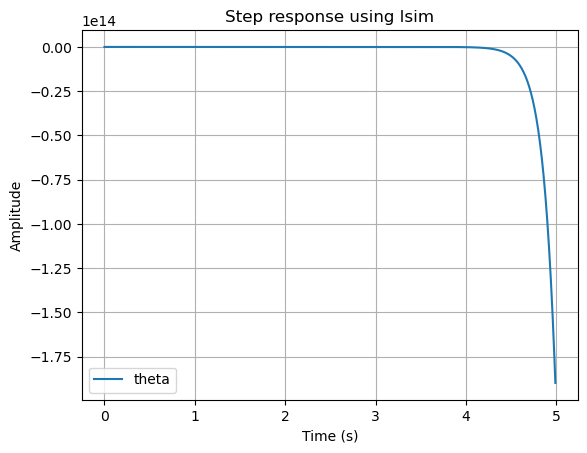

In [14]:
dt = 0.01
tf = 5
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])
yc = np.zeros((1, int(tf / dt)))
for i in range(len(t)):
    if t[i] >= 0:
        yc[0,i] = 1
    else:
        yc[0,i] = 0
signal_sys = signal.StateSpace(A, B, C, D)
yc = np.reshape(yc, np.shape(t))
tout, y, x = signal.lsim(signal_sys, U=yc, T=t)

fig3, ax3 = plt.subplots()
ax3.plot(tout, y, label='theta')

ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.set_title('Step response using lsim')
ax3.grid(True)
ax3.legend()
ax3.grid(True)

**Question 8** On the same graph, plot the linear and non linear simulations during $0.7$ second.

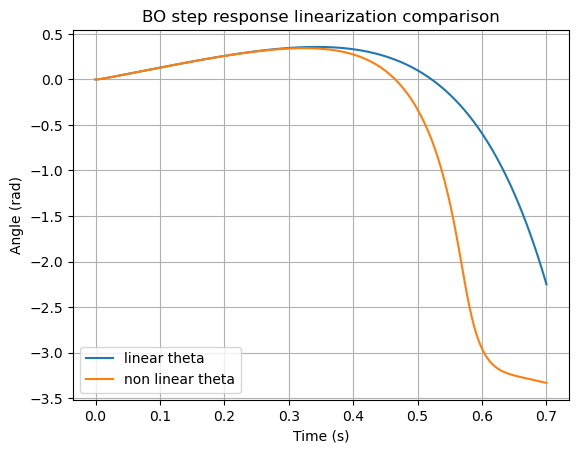

In [15]:
tspan = (0.0, 0.7)
t_eval = np.linspace(tspan[0], tspan[1], num=200)
x0 = [0.0, 0.0, 0.0, 0.0]
amplitude = 1
sol_bo = solve_ivp(xdot, tspan, x0, t_eval=t_eval, method='RK45', args=(0, 1, amplitude))

t = sol_bo.t
xout = sol_bo.y
theta_nlin_bo = sol_bo.y[0, :]
psi_nlin_bo = sol_bo.y[1, :]
x0 = np.array([[0], [0], [0], [0]])
tout, theta = ctrl.step_response(sysbo, t, x0)

fig4, ax4 = plt.subplots()
ax4.plot(t, theta, label='linear theta')
ax4.plot(t, theta_nlin_bo, label='non linear theta')

ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Angle (rad)')
ax4.set_title('BO step response linearization comparison')
ax4.legend()
ax4.grid(True)

**Question 9** Which are the main differences between the previous simulations?

### Robot's animation
A Python file named `animation.py` is provided with this project. Please ensure that it is located **in** the same folder as this notebook. You can then create an instance of the `MyAnimation` class as follows:

`name_of_your_instance = anim.MyAnimation(your_state_feedback_gain, your_pregain, reference_amplitude, animation_time, plotting_type)`

The `plotting_type` parameter must be set to one of the following strings: `'Moving curves'`, `'Moving points'`, or `'Curve filling'`.

Run the next cells to visualize the open-loop response with a reference of 1 (the open-loop instance has already been created for you). The first animation shows the robot's physical movement, while the second one displays the corresponding curves. These curves should match the ones you plotted earlier.

In [17]:
import piplite
await piplite.install(['nbformat', 'control'])

%matplotlib inline
import animation as anim

In [18]:
anim_bo = anim.MyAnimation(np.zeros((1, 4)), 1, 1, 5, 'Moving curves')

In [ ]:
from IPython.display import HTML
HTML(anim_bo.ani2.to_jshtml())

In [ ]:
HTML(anim_bo.ani.to_jshtml())

# 5. Open loop analysis

**Question 10** Is the system stable?

In [16]:
print(ctrl.damp(sysbo))

    Eigenvalue (pole)       Damping     Frequency
                    0             1             0
               -179.4             1         179.4
                7.369             1         7.369
               -6.144             1         6.144
(array([  0.        , 179.4329201 ,   7.36858727,   6.14433189]), array([nan,  1., -1.,  1.]), array([   0.        +0.j, -179.4329201 +0.j,    7.36858727+0.j,
         -6.14433189+0.j]))


**Question 11** Is the system controllable?

In [17]:
Qc = ctrl.ctrb(A, B)
print(np.linalg.matrix_rank(Qc))

4


**Question 12** Is the system observable?

In [18]:
Qo = ctrl.obsv(A, C)
print(np.linalg.matrix_rank(Qo))

4


**Question 13** Compute the transfer function of the system?

NB : You have to erase unnecessary coefficients in this function (very low coefficients), it could bring you issues in the next section.

In [19]:
G = ctrl.ss2tf(A, B, C, D)

# Erase unnecessary coefficients
num = G.num_array[0, 0]
den = G.den_array[0, 0]
for i in range(4):
    if 0.0005 > num[i] > -0.0005:
        num[i] = 0
    if 0.0005 > den[i] > -0.0005:
        den[i] = 0
G = ctrl.TransferFunction(num, den)
print(G)

<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         239.3 s^2 - 1.579e+04
  ------------------------------------
  s^4 + 178.2 s^3 - 264.9 s^2 - 8124 s


# 6. Balance Control

After a modeling and analysis phases, we aim now at controlling the system. The objective is to stabilize the upright position of the NXTway. To this end, a closed-loop control law has to be designed to calculate the appropriate command signal $u(t)$ that maintains the angular position $\psi(t)$ close to 0. At first, the control law will be based only on the output measure $y(t)$. Then, the full state measurement $x(t)$ will be considered.

## 6.1 Output feedback control law

### 6.1.1 Proportional controller

A first classical controller is the proportional control law :

$$u(t) = K_p\varepsilon(t)$$

with $\varepsilon(t)=y_c(t)-y(t)$, $y_c(t)$ being the setpoint for the output, that is, the desired average wheels angle (for instance, $y_c=\frac{\pi}{2}\;\mathrm{rad}$). $K_p$ is a positive constant gain. For some values of $K_p$ between $0.1$ and $10$, show the closed-loop eigenvalues in the console.

**Question 14** Write a script that plots the poles of the closed-loop system with respect to Kp in the complex plane (root locus). The instruction logspace from numpy should be used to generate several values of the gain over a couple of decades $Kp ∈[10^{−1} , 10^{3}]$. Compare your root locus with the result of the instruction rlocus.

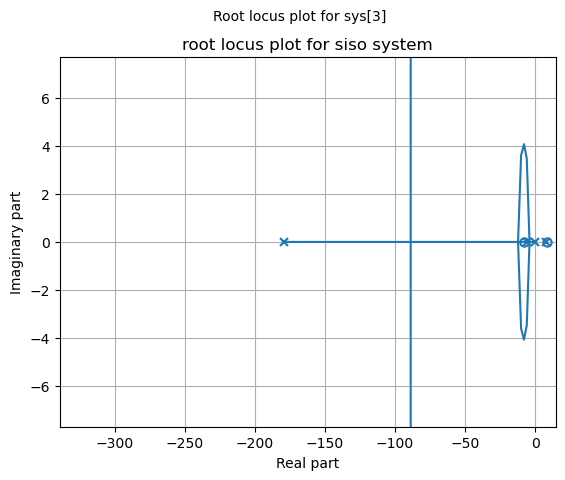

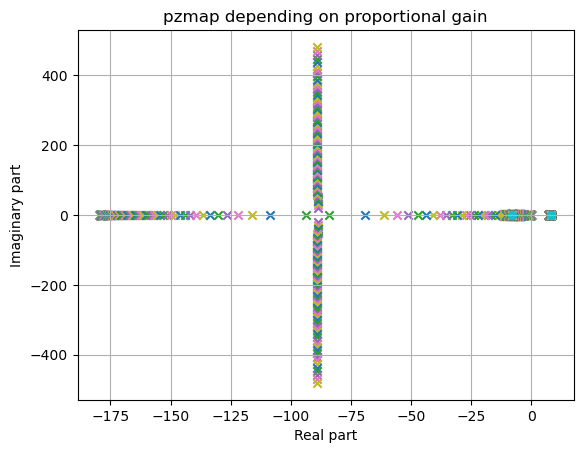

In [20]:
Kp = np.logspace(-1, 3, 200)
fig5, ax5 = plt.subplots()
ctrl.root_locus(G)
ax5.set_xlabel('Real part')
ax5.set_ylabel('Imaginary part')
ax5.set_title('root locus plot for siso system')
ax5.grid(True)
fig6, ax6 = plt.subplots()
for i in Kp:
    F = ctrl.feedback(i * G, 1)
    p = ctrl.poles(F)
    Z = ctrl.zeros(F)
    ax6.scatter(np.real(p), np.imag(p), marker='x')
    ax6.scatter(np.real(Z), np.imag(Z), marker='o')
ax6.set_xlabel('Real part')
ax6.set_ylabel('Imaginary part')
ax6.set_title('pzmap depending on proportional gain')
ax6.grid(True)

It can be observed that the system cannot be stabilized with a simple proportional control law. A pole remains in 
the right half-plane.

**Question 15** Can the system be stabilized? Provide the analytic answer.

It can be observed that the system cannot be stabilized with a simple proportional control law. A pole remains in 
the right half-plane.

**Question 16** Simulate the system with the proportional control for some arbitrary value of $K_p$. Is it consistent with
your calculation?

    Eigenvalue (pole)       Damping     Frequency
               -178.1             1         178.1
                7.492             1         7.492
               -5.417             1         5.417
               -2.185             1         2.185
(array([178.09923079,   7.4920889 ,   5.41653485,   2.18498798]), array([ 1., -1.,  1.,  1.]), array([-178.09923079+0.j,    7.4920889 +0.j,   -5.41653485+0.j,
         -2.18498798+0.j]))


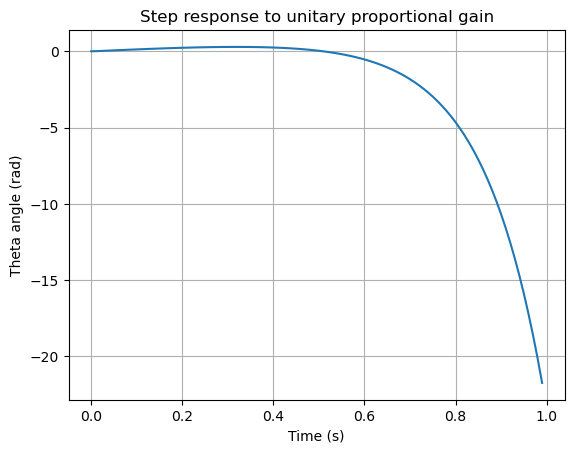

In [21]:
dt = 0.01
tf = 1
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])
Kp = 1
F = ctrl.feedback(Kp * G, 1)
tout, theta = ctrl.step_response(F, t)

fig7, ax7 = plt.subplots()
ax7.plot(tout, theta)

ax7.set_xlabel('Time (s)')
ax7.set_ylabel('Theta angle (rad)')
ax7.set_title('Step response to unitary proportional gain')
ax7.grid(True)
print(ctrl.damp(F))

### 6.1.2 Proportional Integral controller

Let us now consider a slightly more fancy law: a Proportional-Integral (PI) controller. It is a transfer function that includes two tuning parameters. This control law can be written as
$$u(t)=K_p\,\varepsilon(t)+K_i\int_0^t \varepsilon(\tau)\,d\tau$$
where $K_p$ and $K_i$ are the constant gains to be set, and $\varepsilon(t)=y_c(t)-y(t)$ as for the proportional controller.

**Question 17** Calculate the characteristic polynomial of closed-loop system and apply the Routh criterion to derive
stability conditions w.r.t. the two above parameters. Can the system be stabilized?

The PI control law is given by

$$
u(t)=K_p\varepsilon(t)+K_i\int_0^t\varepsilon(\tau)d\tau
$$

That is, in the Laplace-domain $u = (K_p + K_i\frac{1}{p})\varepsilon$

The transfer function $G(p)$ of the robot is of the form : $G(p) = \frac{b_2p^2 + b_1p + b_0}{p^4 + a_3p^3 + a_2p^2 + a_1p}$ with $b_1\cong0$. Then, the closed-loop characteristic equation can be easily expressed : 

$p^5 + a_3p^4 + p^3(a_2+K_pb_2) + p^2(a_1+K_ib_2) + p(K_pb_0) + K_ib_0$

A necessary condition for stability (and to build then the Routh table) is that all coefficients be of the same sign. 
Consequently, it is required to have :

$a_2+K_pb_2>0 \Rightarrow K_p>\frac{-a_2}{b_2}\cong2.08$

$K_ib_0>0 \Rightarrow K_i<0$

$K_pb_0>0 \Rightarrow K_p<0$
$a_1+K_ib_2>0 \Rightarrow K_i>\frac{-a_1}{b_2}\cong70.8$

The stability conditions are not feasible, thus the robot cannot be stabilized with this controller neither.

## 6.2 State feedback control law

In this part we consider a state feedback controller. The objective is that the controlled system behaves as a second system order with an overshoot of $5%$ and a settling time around $3$ seconds for a step input reference of $\frac{\pi}{5}$.
The other two poles should be kept to their initial stable values, we only aim to change the instable open-loop poles.

**Question 18** Design a state feedback controller $u(t)=-Kx(t)+y_c(t)$  following the method seen during the lectures. Check that the specifications are satisfied.

In [22]:
a4 = den[0]
a3 = den[1]
a2 = den[2]
a1 = den[3]
a0 = den[4]

# MCH horizontal companion form
m4 = B
m3 = np.dot((A + a3 * np.identity(4)), B)
A_2 = np.dot(A, A)
m2 = np.dot((A_2 + a3 * A + a2 * np.identity(4)), B)
A_3 = np.dot(A_2, A)
m1 = np.dot((A_3 + a3 * A_2 + a2 * A + a1 * np.identity(4)), B)

MCH = np.hstack((m1, m2, m3, m4))  # to stack column by column

The desired overshoot is

$$
M_p=5\%.
$$

Using

$$
M_p=e^{-\frac{\pi\zeta}{\sqrt{1-\zeta^2}}},
$$

we obtain

$$
\zeta\simeq0.69.
$$

The desired settling time is

$$
T_s=3\;s.
$$

Using the approximation

$$
T_s=\frac{4}{\zeta\omega_n},
$$

we obtain

$$
\omega_n=\frac{4}{0.69\times3}
\simeq1.932\;rad/s.
$$

Therefore, the dominant poles are

$$
p_{1,2}
=
-\zeta\omega_n
\pm
j\omega_n\sqrt{1-\zeta^2},
$$

which gives

$$
p_{1,2}
=
-1.33
\pm
j\,1.40
$$

In [30]:
z = 0.69
wn = 1.932
p1 = -179.4329
p2 = -6.1443

coef1 = np.array([1, 2 * z * wn, wn ** 2])
coef2 = np.array([1, -p1])
coef3 = np.array([1, -p2])

polyClosedLoop = np.convolve(coef1, np.convolve(coef2, coef3))
print(polyClosedLoop)
print(np.roots(polyClosedLoop))

[1.00000000e+00 1.88243360e+02 1.60100070e+03 3.63210350e+03
 4.11517902e+03]
[-179.4329 +0.j          -6.1443 +0.j          -1.33308+1.3983997j
   -1.33308-1.3983997j]


In [31]:
Ktilde = np.array([polyClosedLoop[4] - a0, polyClosedLoop[3] - a1, polyClosedLoop[2] - a2, polyClosedLoop[1] - a3])
print(Ktilde)

[4.11517902e+03 1.17559372e+04 1.86594746e+03 1.00346953e+01]


In [32]:
MCHinv = np.linalg.inv(MCH)
K = np.dot(Ktilde, MCHinv)
K = np.reshape(K, (1, 4))
print(K)

[[ -0.26058726 -18.00482921  -0.74442628  -1.75716003]]


In [33]:
imag_part = ((4 * wn ** 2 - 4 * z ** 2 * wn ** 2) ** (1 / 2)) / 2
p3 = complex(-wn * z, imag_part)
p4 = np.conj(p3)
p_d = [p1, p2, p3, p4]
K_p = ctrl.place(A, B, p_d)
print(K_p)

[[ -0.26058726 -18.00482921  -0.74442628  -1.75716003]]


**Question 19** Provide the closed-loop pzmap and a simulation of the designed control law. Comment.

In [34]:
ACL = np.dot(B, K)
ACL = A - ACL
BCL = B
CCL = C

sysGCL = ctrl.ss(ACL, BCL, CCL, D)
print(sysGCL)

<StateSpace>: sys[809]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
     [ 6.23639090e+01  3.86433874e+03  5.50430907e+01  5.43638147e+02]
     [-2.79088106e+01 -1.66336461e+03 -2.46326316e+01 -2.43286451e+02]]

B = [[   0.        ]
     [   0.        ]
     [ 239.3206408 ]
     [-107.09967584]]

C = [[1. 0. 0. 0.]]

D = [[0.]]


In [35]:
TFCL = ctrl.ss2tf(ACL, BCL, CCL, D)

numGCL = TFCL.num_array[0, 0]
denGCL = TFCL.den_array[0, 0]
for i in range(3):
    if 0.0005 > numGCL[i] > -0.0005:
        numGCL[i] = 0
    if 0.0005 > denGCL[i] > -0.0005:
        denGCL[i] = 0

TFCL = ctrl.TransferFunction(numGCL, denGCL)
print(TFCL)

<TransferFunction>: sys[812]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            239.3 s^2 - 1.579e+04
  ------------------------------------------
  s^4 + 188.2 s^3 + 1601 s^2 + 3632 s + 4115


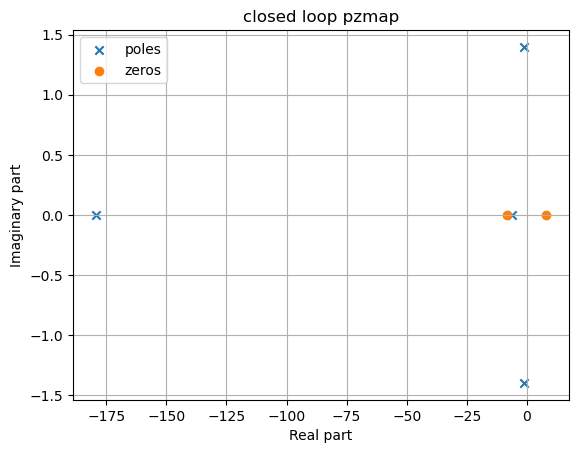

In [36]:
fig8, ax8 = plt.subplots()
poles_cl = ctrl.poles(sysGCL)
poles_real_cl = np.real(poles_cl)
poles_im_cl = np.imag(poles_cl)
ax8.scatter(poles_real_cl, poles_im_cl, marker='x', label='poles')
zeros_cl = ctrl.zeros(sysGCL)
zeros_real_cl = np.real(zeros_cl)
zeros_im_cl = np.imag(zeros_cl)
ax8.scatter(zeros_real_cl, zeros_im_cl, marker='o', label='zeros')
ax8.set_xlabel('Real part')
ax8.set_ylabel('Imaginary part')
ax8.set_title('closed loop pzmap')
ax8.legend()
ax8.grid(True)

In [37]:
poles_cl = ctrl.poles(sysGCL)
zeros_cl = ctrl.zeros(sysGCL)

print(poles_cl)
print(np.linalg.eig(ACL))
print(ctrl.damp(sysGCL))

[-179.4329 +0.j          -6.1443 +0.j          -1.33308+1.3983997j
   -1.33308-1.3983997j]
EigResult(eigenvalues=array([-179.4329 +0.j       ,   -6.1443 +0.j       ,
         -1.33308+1.3983997j,   -1.33308-1.3983997j]), eigenvectors=array([[-0.00508514+0.j        , -0.13784497+0.j        ,
        -0.31707366-0.33260998j, -0.31707366+0.33260998j],
       [ 0.00228035+0.j        , -0.08248395+0.j        ,
        -0.00750786+0.00882017j, -0.00750786-0.00882017j],
       [ 0.91244112+0.j        ,  0.84696088+0.j        ,
         0.88780626+0.j        ,  0.88780626-0.j        ],
       [-0.40917007+0.j        ,  0.50680611+0.j        ,
        -0.00232554-0.02225697j, -0.00232554+0.02225697j]]))
    Eigenvalue (pole)       Damping     Frequency
               -179.4             1         179.4
               -6.144             1         6.144
    -1.333    +1.398j          0.69         1.932
    -1.333    -1.398j          0.69         1.932
(array([179.4329,   6.1443,   1.932 ,   1.932 

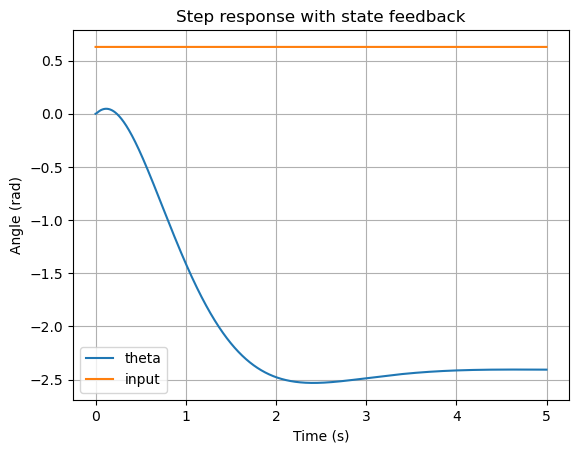

In [38]:
dt = 0.001
tf = 5
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])
yc = []
for i in range(len(t)):
    yc.append(np.pi / 5)
tout, theta = ctrl.step_response(np.pi / 5 * sysGCL, t, x0)

fig9, ax9 = plt.subplots()
ax9.plot(tout, theta, label='theta')
ax9.plot(tout, yc, label='input')

ax9.set_xlabel('Time (s)')
ax9.set_ylabel('Angle (rad)')
ax9.set_title('Step response with state feedback')
ax9.legend()
ax9.grid(True)

In [39]:
print(ctrl.step_info(np.pi/5*sysGCL))

{'RiseTime': 1.0991699093929972, 'SettlingTime': 3.2750776892117877, 'SettlingMin': -2.530882683607535, 'SettlingMax': -2.183855023638839, 'Overshoot': 4.965195334404106, 'Undershoot': 1.9378418603579937, 'Peak': 2.530882683607535, 'PeakTime': 2.422660208458035, 'SteadyStateValue': -2.4111636962561778}


In [40]:
print(ctrl.zpk(poles_cl, zeros_cl, 1))

<TransferFunction>: sys[815]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s^4 + 188.2 s^3 + 1601 s^2 + 3632 s + 4115
  ------------------------------------------
          s^2 - 1.776e-15 s - 65.99


**Question 20** Modify the control law $u(t)$ to obtain a null steady state error.

To eliminate the steady-state error, a precompensator gain $l_c$ is introduced.

The control law becomes

$$
u(t)=-Kx(t)+l_cy_c.
$$

At equilibrium,

$$
0=(A-BK)x_{eq}+Bl_cy_c.
$$

Hence

$$
x_{eq}
=
-(A-BK)^{-1}Bl_cy_c.
$$

Since

$$
y=Cx,
$$

we obtain

$$
y_{eq}
=
-C(A-BK)^{-1}Bl_cy_c.
$$

Imposing

$$
y_{eq}=y_c
$$

gives

$$
l_c=
-\frac{1}
{C(A-BK)^{-1}B}.
$$

Thus, the steady-state error is theoretically equal to zero.

In [41]:
# We can either use the dcgain function or compute the calculation :

lc = -1/(C @ np.linalg.inv(A-B@K) @ B)[0]

dc_gain = ctrl.dcgain(sysGCL)
lc_verif = 1 / dc_gain

print(lc)
print(lc_verif)

-0.2605872557278269
-0.2605872557278268


In [42]:
sysGCL_eps = ctrl.ss(ACL, BCL * lc, CCL, D)
print(sysGCL_eps)

<StateSpace>: sys[816]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
     [ 6.23639090e+01  3.86433874e+03  5.50430907e+01  5.43638147e+02]
     [-2.79088106e+01 -1.66336461e+03 -2.46326316e+01 -2.43286451e+02]]

B = [[ -0.        ]
     [ -0.        ]
     [-62.36390902]
     [ 27.90881062]]

C = [[1. 0. 0. 0.]]

D = [[0.]]


**Question 21** Provide a new simulation with the new designed control law. Comment.

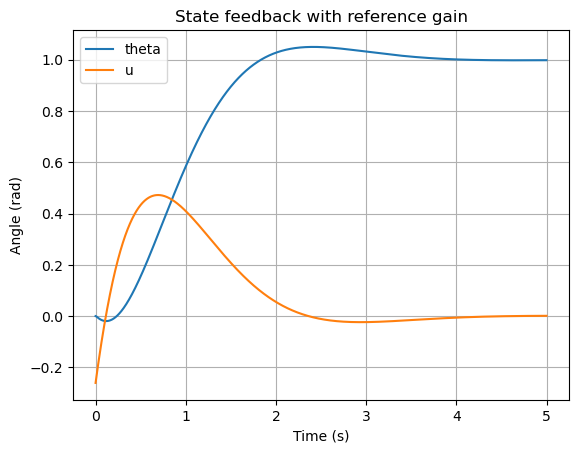

In [44]:
dt = 0.001
tf = 5
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])
tout, theta, xout = ctrl.step_response(sysGCL_eps, t, x0, return_x=True)
u = np.array([-1 * np.dot(K, xout)] + lc)
u = np.reshape(u, np.shape(tout))

fig10, ax10= plt.subplots()
ax10.plot(tout, theta, label='theta')
ax10.plot(tout, u, label='u')

ax10.set_xlabel('Time (s)')
ax10.set_ylabel('Angle (rad)')
ax10.set_title('State feedback with reference gain')
ax10.legend()
ax10.grid(True)

**Question 22** The motors accept an input value in $[−8,+8]$ volts. Plot the control signal to eventually detect a
saturation problem.

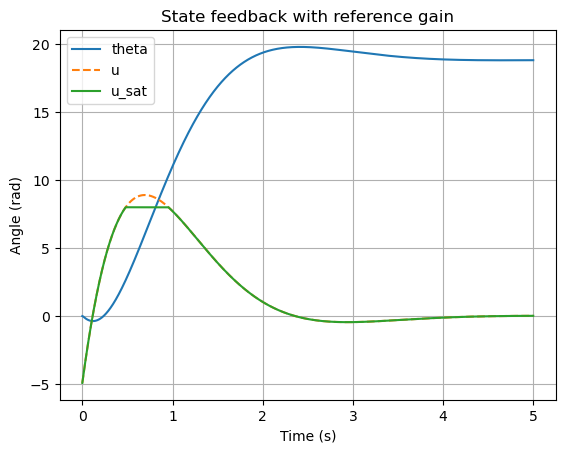

In [47]:
dt = 0.001
tf = 5
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])
yc = 6*np.pi
tout, theta, xout = ctrl.step_response(sysGCL_eps*yc, t, x0, return_x=True)
u = np.array([-1 * np.dot(K, xout)] + yc * lc)
u = np.reshape(u, np.shape(tout))
u_sat = np.clip(u,-8,8)

fig11, ax11= plt.subplots()
ax11.plot(tout, theta, label='theta')
ax11.plot(tout, u, '--', label='u')
ax11.plot(tout, u_sat, label='u_sat')

ax11.set_xlabel('Time (s)')
ax11.set_ylabel('Angle (rad)')
ax11.set_title('State feedback with reference gain')
ax11.legend()
ax11.grid(True)

**Question 23** Determine the limit value of the settling time so that the state feedback with pregain control law satisfies
the saturation constraint, for a reference of 1.

The settling time is related to the natural frequency by

$$
T_s=\frac{4}{\zeta\omega_n}.
$$

Reducing the settling time increases the natural frequency and consequently the feedback gain matrix $K$.

As a result, the control effort

$$
u(t)=-Kx(t)+l_cy_c
$$

increases.

The minimum admissible settling time corresponds to the smallest value of $T_s$ for which

$$
\max_t|u(t)|\leq8V.
$$

This value can be determined iteratively by increasing the settling time and checking the maximum amplitude of the control signal.

In [48]:
Ts_values = np.linspace(0.1,1,200)
dt = 0.001
tf = 1
t = np.arange(0, tf, dt)
x0 = np.array([[0], [0], [0], [0]])

for Ts in Ts_values:
    wn = 4/(z*Ts)
    imag_part = ((4 * wn ** 2 - 4 * z ** 2 * wn ** 2) ** (1 / 2)) / 2
    p3 = complex(-wn * z, imag_part)
    p4 = np.conj(p3)
    p_d = [p1, p2, p3, p4]
    K_p = ctrl.place(A, B, p_d)
    sys_temp = ctrl.ss(A-B@K_p, B, C, D)
    dc_gain_try = ctrl.dcgain(sys_temp)
    lc_try = 1 / dc_gain_try
    sys_bf_temp = ctrl.ss(A-B@K_p, B*lc_try, C, D)
    tout, theta, xout = ctrl.step_response(sys_bf_temp, t, x0, return_x=True)
    u = np.array([-1 * np.dot(K_p, xout)] + 1 * lc_try)
    u = np.reshape(u, np.shape(tout))
    if np.max(u) < 8 and np.min(u) > -8:
        Ts_min = Ts
        break
if np.max(u) > 8 or np.min(u) < -8:
    print('There is no matching settling time in this interval !')
else:
    print(f'The minimum settling time is : {Ts}')
    print(f"The maximum corresponding command's amplitude time is : {np.max(u)}")
    print(f"The minimum corresponding command's amplitude time is : {np.min(u)}")

The minimum settling time is : 0.5432160804020101
The maximum corresponding command's amplitude time is : 3.615688226354253
The minimum corresponding command's amplitude time is : -7.950885407968485


# 7. Nonlinear simulations

In the previous section, a state feedback control law has been designed based on a linear model of the robot. You have been able to verify your calculations with your linear state space model. A better validation step consists in testing your control on the nonlinear model. To this end, the xdot function is provided.

**Question 24** Provide a 5 second simulation of the non linear model, with an input of $\frac{\pi}{5}$.

In [53]:
tspan = (0.0, 5.0)
t_eval = np.linspace(tspan[0], tspan[1], num=200)

x0 = [0.0, 0.0, 0.0, 0.0]
amplitude = np.pi/5
sol = solve_ivp(xdot, tspan, x0, t_eval=t_eval, method='RK45', args=(K, lc, amplitude))

t = sol.t
xout = sol.y
theta_nlin = sol.y[0, :]
psi_nlin = sol.y[1, :]

In [54]:
command = np.zeros(len(t))
yc = [amplitude] * len(t)
for i in range(len(t)):
    x_actuelle = xout[:, i]
    utheo = -np.dot(K, x_actuelle) + yc[i]*lc
    utheo = np.clip(utheo, -8.0, 8.0)
    command[i] = utheo[0]

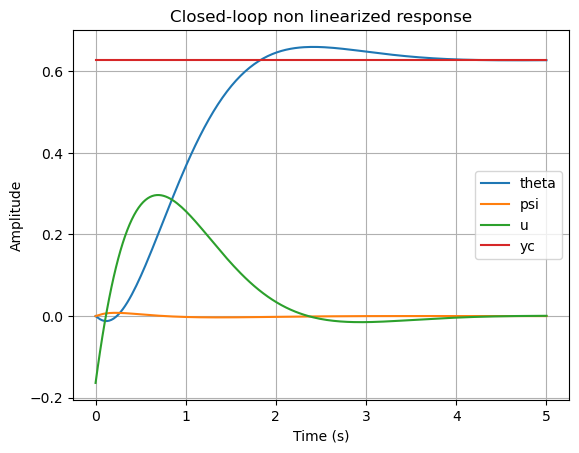

In [55]:
fig12, ax12 = plt.subplots()
ax12.plot(t, theta_nlin, label='theta')
ax12.plot(t, psi_nlin, label='psi')
ax12.plot(t, command, label='u')
ax12.plot(t, yc, label='yc')

ax12.set_xlabel('Time (s)')
ax12.set_ylabel('Amplitude')
ax12.set_title('Closed-loop non linearized response')
ax12.grid(True)
ax12.legend();

**Question 25** On the same plot, compare the responses you get from the linear and non linear simulations ($\theta(t)$, $\psi(t)$ and $u(t)$)

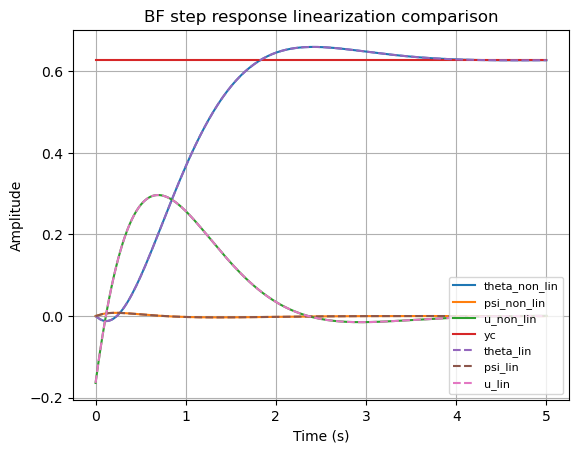

In [56]:
fig13, ax13 = plt.subplots()
ax13.plot(t, theta_nlin, label='theta_non_lin')
ax13.plot(t, psi_nlin, label='psi_non_lin')
ax13.plot(t, command, label='u_non_lin')
ax13.plot(t, yc, label='yc')

yc = np.array(yc)
signal_sys = signal.StateSpace(ACL, BCL * lc, CCL, D)
tout, y, x = signal.lsim(signal_sys, U=yc, T=t)

x = np.transpose(x)
theta_lin_bf = x[0,:]
psi_lin_bf = x[1,:]
u = np.array([-1 * np.dot(K, x)] + lc * yc)
u = np.reshape(u, np.shape(tout))

ax13.plot(tout, theta_lin_bf, '--',label='theta_lin')
ax13.plot(tout, psi_lin_bf, '--', label='psi_lin')
ax13.plot(tout, u, '--', label='u_lin')

ax13.set_xlabel('Time (s)')
ax13.set_ylabel('Amplitude')
ax13.set_title('BF step response linearization comparison')
ax13.grid(True)
ax13.legend(fontsize=8, loc='lower right')

You must now create your closed-loop instance of the animation using the `MyAnimation` class, as defined previously.

In [117]:
anim_bf = anim.MyAnimation(K, lc, 3, 5, 'Moving curves')

To plot the animation, run the two cells below : the first one displays the simulated robot, and the second one plots the responses obtained from the non-linear simulation.

In [ ]:
HTML(anim_bf.ani2.to_jshtml())

In [ ]:
HTML(anim_bf.ani.to_jshtml())

# 8. Simulation of the robot using an interface

On Moodle, you can download a ZIP file containing three Python files: `interface.py`, `animation.py`, and `NXTwaysim.py`.

Open a terminal on linux, navigate to the directory where you downloaded these Python files, and run the following command:

`python ./interface_tkinter.py`

(On Windows, open a Command Prompt (cmd), navigate to the folder with `cd <path>` (or `cd /d <path>` if the folder is on a different drive), and run `python interface_tkinter.py`. Make sure you have a standard Python installation (from python.org) with tkinter included, as some restricted/managed Python installs (e.g. via IT deployment tools) may not include it and could cause errors when launching the interface.)

A graphical interface will appear, including instructions on how to start and reset the simulation. This tool allows you to modify the dynamics of your model and plot real-time responses in the same format as shown above. You can adjust, in real time, the reference signal sent to your model as well as the timespan of the graph. This will enable you to test the robustness of your control law and further analyze your model. In case you close one of the three windows, you have to close the two remaining ones and rerun the python command.

# Appendix: Quick Reference for Python Libraries

This section provides a quick reference to the main functions used throughout this project from NumPy, Control, and the Scipy library.

---

# 1. NumPy: Array Creation and Manipulation

In Python, state-space representations and simulations rely heavily on vectors and matrices provided by NumPy.

## 🔹 Creating Matrices and Vectors

### State Matrix A (2×2 example)

```python
A = np.array([[0, 1],
              [-2, -3]])
```

### Column Vector (4×1 shape)

```python
x = np.array([[1],
              [2],
              [3],
              [4]])
```

### Alternative Method Using `reshape`

```python
x = np.array([1, 2, 3, 4]).reshape((4, 1))
```

### Matrices of Zeros or Ones

```python
Z = np.zeros((3, 3))
O = np.ones((3, 3))
```

## 🔹 Matrix Operations

### Matrix Multiplication

```python
C = A @ B
```

⚠️ **Warning:** Do **not** use the asterisk `*`, which performs element-wise multiplication. Use the `@` operator or dedicated matrix multiplication functions.

### `np.dot` vs `@`

You will also see `np.dot(A, B)` used in some parts of this project instead of `A @ B`:

```python
C = np.dot(A, B)
```

For 2D arrays (matrices), `np.dot` and `@` are strictly equivalent. `@` is generally preferred for readability since it was introduced specifically as a matrix multiplication operator, but you may use either — just don't confuse `np.dot`/`@` with the element-wise `*`.

### Saturating a Signal with `np.clip`

To enforce actuator or physical limits (e.g. a motor voltage bounded to $[-8, 8]$ V), use `np.clip`:

```python
u_sat = np.clip(u, -8.0, 8.0)
```

Any value below the lower bound is set to it, any value above the upper bound is set to it, and values in between are left unchanged.

---

# 2. Control Library: Linear System Analysis

The Python `control` package reproduces the core functionalities of MATLAB's Control System Toolbox. You can find most MATLAB functions in this library, and more information can be easily found on the internet.

## 🔹 System Definition

### Continuous-Time State-Space System

```python
sys = ctrl.ss(A, B, C, D)
```

### Transfer Function Representation

```python
G = ctrl.tf(num, den)
```

## 🔹 Stability, Controllability, and Observability

### Poles and Stability

```python
poles = ctrl.poles(sys)
```

### Controllability Matrix and Its Rank

```python
Ctrb = ctrl.ctrb(A, B)
rank_ctrb = np.linalg.matrix_rank(Ctrb)
```

### Observability Matrix and Its Rank

```python
Obsv = ctrl.obsv(A, C)
rank_obsv = np.linalg.matrix_rank(Obsv)
```

### Damping, Natural Frequency and Poles

```python
ctrl.damp(sys)
```

Displays, for each pole of the system, its damping ratio, natural frequency, and value. Useful to numerically check overshoot/settling-time-related specifications instead of reading them off a plot.

## 🔹 Controller Design

### Pole Placement

```python
K = ctrl.place(A, B, desired_poles)
```

Computes the state feedback gain matrix $K$ such that the closed-loop system $\dot{x} = (A-BK)x$ has poles located at `desired_poles` (a list of desired closed-loop pole values, which can include complex conjugate pairs).

### Static (DC) Gain

```python
dc_gain = ctrl.dcgain(sys)
```

Returns the steady-state gain of the system, i.e. the ratio between the output and the input once the transient response has died out for a step input.

### Closed-Loop Interconnection

```python
sys_cl = ctrl.feedback(K * G, 1)
```

Builds the closed-loop transfer function from an open-loop transfer function `G` and a unity negative feedback loop.

## 🔹 Step Response and Root Locus

### Open-Loop Step Response Simulation

```python
t, y = ctrl.step_response(sys)
```

### Step Response Characteristics

```python
info = ctrl.step_info(sys)
```

Returns a dictionary with key time-domain characteristics of the step response (`'Overshoot'`, `'SettlingTime'`, `'RiseTime'`, `'Peak'`, etc.), useful to numerically verify design specifications rather than estimating them visually from a plot.

### Root Locus for Proportional Controller Design

```python
ctrl.root_locus(G)
```

---

# 3. SciPy: Nonlinear Simulation with `solve_ivp`

To simulate the exact nonlinear system equations, where linear control tools are no longer applicable, we use SciPy's ordinary differential equation solver.

## 🔹 Running the Nonlinear Integration

```python
sol = solve_ivp(
    f(x,u),
    t_span,
    x0,
    t_eval,
    method='RK45',
    args=(K, lc, amplitude)
)
```

## 🔹 Extracting the Results

```python
t = sol.t
x = sol.y
```

## Signal from SciPy: state space representation and linear simulation

```python
system = signal.StateSpace(A, B, C, D)
tout, y, x = signal.lsim(system, U=yc, T=t)
```